In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_all_region = pd.read_csv('../data/superstore.csv')

#FirstLook

print("Shape:",df_all_region.shape)
print("\n Column:",df_all_region.columns.tolist())
print("\n----First 5 rows----")
df_all_region.head()




Shape: (1000, 9)

 Column: ['order_id', 'order_date', 'category', 'sub_category', 'region', 'sales', 'discount', 'profit', 'quantity']

----First 5 rows----


,order_id,order_date,category,sub_category,region,sales,discount,profit,quantity
0,1,2021-01-26,Office Supplies,Pens,East,1496.02,0.1,224.80,2
1,2,2022-08-28,Office Supplies,Pens,East,872.75,0.0,111.81,4
2,3,2022-07-29,Office Supplies,Paper,East,437.73,0.3,50.90,10
3,4,2021-06-13,Technology,Phones,East,1411.37,0.2,207.03,4
4,5,2021-04-05,Technology,Phones,East,790.86,0.2,224.13,10


In [4]:
#Data basic info:
print("----Data Types---")
print(df_all_region.dtypes)

print("----Missing Values----")
print(df_all_region.isnull().sum())

print("----Basic Statistice----")
df_all_region.describe()


----Data Types---
order_id          int64
order_date          str
category            str
sub_category        str
region              str
sales           float64
discount        float64
profit          float64
quantity          int64
dtype: object
----Missing Values----
order_id        0
order_date      0
category        0
sub_category    0
region          0
sales           0
discount        0
profit          0
quantity        0
dtype: int64
----Basic Statistice----


,order_id,sales,discount,profit,quantity
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,1041.308150,0.153700,216.843200,5.542000
std,288.819436,557.957039,0.113045,148.395135,2.870623
min,1.000000,51.400000,0.000000,4.560000,1.000000
25%,250.750000,549.130000,0.100000,102.362500,3.000000
50%,500.500000,1065.210000,0.200000,187.200000,6.000000
75%,750.250000,1510.402500,0.300000,302.690000,8.000000
max,1000.000000,1995.520000,0.300000,740.140000,10.000000


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df_all_region = pd.read_csv('../data/superstore.csv')
df_all_region ['order_date'] =pd.to_datetime(df_all_region['order_date'])

df_all_region['year']= df_all_region['order_date'].dt.year
df_all_region['month']= df_all_region['order_date'].dt.month


print("Date dtype:", df_all_region['order_date'].dtype)
print("\nYear unique values:", df_all_region['year'].unique())
df_all_region.head()

Date dtype: datetime64[us]

Year unique values: [2021 2022 2023]


,order_id,order_date,category,sub_category,region,sales,discount,profit,quantity,year,month
0,1,2021-01-26,Office Supplies,Pens,East,1496.02,0.1,224.80,2,2021,1
1,2,2022-08-28,Office Supplies,Pens,East,872.75,0.0,111.81,4,2022,8
2,3,2022-07-29,Office Supplies,Paper,East,437.73,0.3,50.90,10,2022,7
3,4,2021-06-13,Technology,Phones,East,1411.37,0.2,207.03,4,2021,6
4,5,2021-04-05,Technology,Phones,East,790.86,0.2,224.13,10,2021,4


In [4]:
category_sales = df_all_region.groupby('category')['sales'].sum().sort_values(ascending= False)
print("---- Sales by Category ----")
print(category_sales)

---- Sales by Category ----
category
Office Supplies    372400.91
Technology         344715.26
Furniture          324191.98
Name: sales, dtype: float64


In [5]:
# Category अनुसार Sales र Profit दुवै हेर्ने
category_summary = df_all_region.groupby('category')[['sales', 'profit']].sum().sort_values('profit', ascending=False)
print("---- Sales vs Profit by Category ----")
print(category_summary)

---- Sales vs Profit by Category ----
                     sales    profit
category                            
Office Supplies  372400.91  76685.25
Technology       344715.26  71086.94
Furniture        324191.98  69071.01


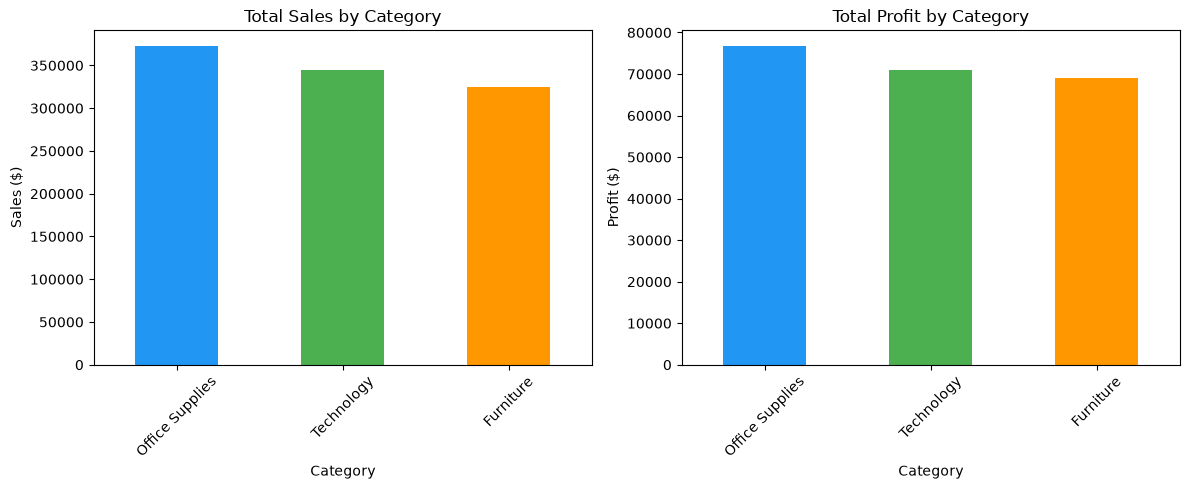

In [ ]:
fig, (ax1,ax2)= plt.subplots(1,2, figsize =(12,5))
category_summary['sales'].plot(kind='bar', ax=ax1, color=['#2196F3','#4CAF50','#FF9800'])

ax1.set_title('Total Sales by Category')
ax1.set_xlabel('Category')
ax1.set_ylabel('Sales ($)')
ax1.tick_params(axis='x', rotation=45)


category_summary['profit'].plot(kind='bar', ax=ax2, color=['#2196F3','#4CAF50','#FF9800'])
ax2.set_title('Total Profit by Category')
ax2.set_xlabel('Category')
ax2.set_ylabel('Profit ($)')
ax2.tick_params(axis='x', rotation=45)



In [ ]:
category_summary ['efficiency'] = category_summary ['profit'] / category_summary ['sales']


category_summary ['efficiency_percentage'] = category_summary ['efficiency'] * 100


print("---- Category Efficiency Analysis ----")
category_summary .sort_values(by='efficiency', ascending=False)

---- Category Efficiency Analysis ----


,sales,profit,efficiency,efficiency_percentage
category,,,,
Furniture,324191.98,69071.01,0.213056,21.305589
Technology,344715.26,71086.94,0.206219,20.621930
Office Supplies,372400.91,76685.25,0.205921,20.592122


In [16]:
region_summary = df_all_region.groupby('region')[['sales', 'profit']].sum().sort_values('sales', ascending=False)
print("---- Sales & Profit by Region ----")
print(region_summary)

---- Sales & Profit by Region ----
            sales    profit
region                     
West    279034.74  56641.66
East    257897.46  54579.79
North   254917.37  53572.46
South   249458.58  52049.29


In [17]:
region_summary ['efficiency'] = region_summary['profit'] / region_summary['sales']


region_summary ['efficiency_percentage'] = region_summary ['efficiency'] * 100


print("---- Region Efficiency Analysis ----")
region_summary.sort_values(by='efficiency', ascending=False)

---- Region Efficiency Analysis ----


,sales,profit,efficiency,efficiency_percentage
region,,,,
East,257897.46,54579.79,0.211634,21.163369
North,254917.37,53572.46,0.210156,21.015618
South,249458.58,52049.29,0.208649,20.864903
West,279034.74,56641.66,0.202991,20.299143


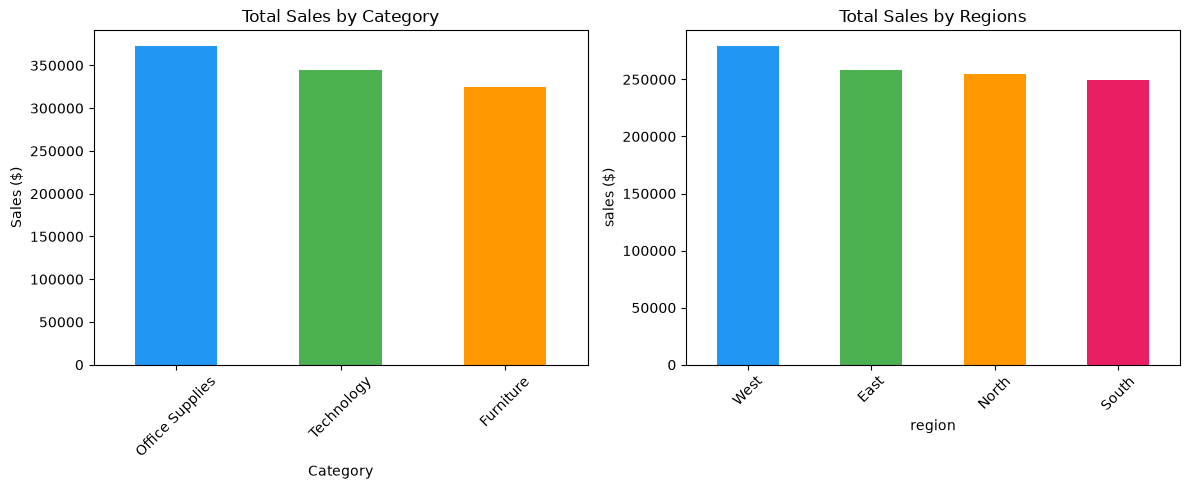

In [21]:
fig, (ax1,ax2)= plt.subplots(1,2, figsize =(12,5))
category_summary['sales'].plot(kind='bar', ax=ax1, color=['#2196F3','#4CAF50','#FF9800'])

ax1.set_title('Total Sales by Category')
ax1.set_xlabel('Category')
ax1.set_ylabel('Sales ($)')
ax1.tick_params(axis='x', rotation=45)


region_summary['sales'].plot(kind='bar', ax=ax2, color=['#2196F3','#4CAF50','#FF9800','#E91E63'])
ax2.set_title('Total Sales by Regions')
ax2.set_xlabel('region')
ax2.set_ylabel('sales ($)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../output/region_analysis.png' , dpi=150)
plt.show()

In [28]:
monthly_sales = df_all_region.groupby(['year', 'month'])['sales'].sum().reset_index()
print("----Monthly Sales----")
print(monthly_sales.head(10))

----Monthly Sales----
   year  month     sales
0  2021      1  28686.73
1  2021      2  34360.12
2  2021      3  47296.92
3  2021      4  45708.18
4  2021      5  37105.78
5  2021      6  47311.92
6  2021      7  49652.77
7  2021      8  28040.92
8  2021      9  41366.86
9  2021     10  46187.95


In [33]:
monthly_sales['date'] = pd.to_datetime(monthly_sales[['year', 'month']].assign(day=1))
print(monthly_sales.head())

   year  month     sales       date
0  2021      1  28686.73 2021-01-01
1  2021      2  34360.12 2021-02-01
2  2021      3  47296.92 2021-03-01
3  2021      4  45708.18 2021-04-01
4  2021      5  37105.78 2021-05-01


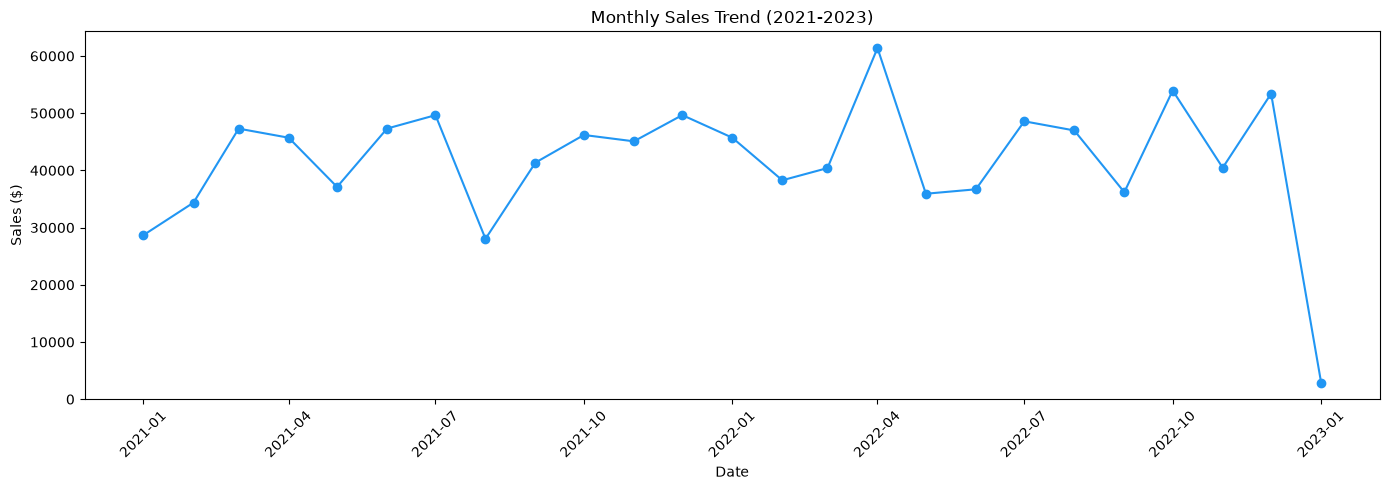

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['date'], monthly_sales['sales'], color='#2196F3', marker='o')
plt.title('Monthly Sales Trend (2021-2023)')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../output/monthly_trend.png', dpi=150)
plt.show()


In [32]:
print("---- Highest Sales Month ----")
print(monthly_sales.loc[monthly_sales['sales'].idxmax()])

print("\n---- Lowest Sales Month ----")
print(monthly_sales.loc[monthly_sales['sales'].idxmin()])

---- Highest Sales Month ----
year                    2022
month                      4
sales               61382.35
date     2022-04-01 00:00:00
Name: 15, dtype: object

---- Lowest Sales Month ----
year                    2023
month                      1
sales                2905.26
date     2023-01-01 00:00:00
Name: 24, dtype: object


In [ ]:
yearly_sales = df_all_region.groupby('year')['sales'].sum()
print(yearly_sales)
# just to confirm trend

year
2021    500459.01
2022    537943.88
2023      2905.26
Name: sales, dtype: float64


In [35]:
subcategory_summary = df_all_region.groupby('sub_category')[['sales', 'profit']].sum().sort_values('profit', ascending=False)
print("---- Profit by Sub-Category ----")
print(subcategory_summary)

---- Profit by Sub-Category ----
                  sales    profit
sub_category                     
Paper         185939.42  39715.24
Tables        172207.70  37317.77
Pens          186461.49  36970.01
Phones        165348.08  36048.43
Laptops       179367.18  35038.51
Chairs        151984.28  31753.24


In [36]:
subcategory_summary ['efficiency'] = subcategory_summary ['profit'] / subcategory_summary ['sales']


subcategory_summary ['efficiency_percentage'] = subcategory_summary ['efficiency'] * 100


print("---- Category Efficiency Analysis ----")
subcategory_summary .sort_values(by='efficiency', ascending=False)

---- Category Efficiency Analysis ----


,sales,profit,efficiency,efficiency_percentage
sub_category,,,,
Phones,165348.08,36048.43,0.218015,21.801541
Tables,172207.70,37317.77,0.216702,21.670210
Paper,185939.42,39715.24,0.213592,21.359236
Chairs,151984.28,31753.24,0.208925,20.892450
Pens,186461.49,36970.01,0.198272,19.827156
Laptops,179367.18,35038.51,0.195345,19.534516


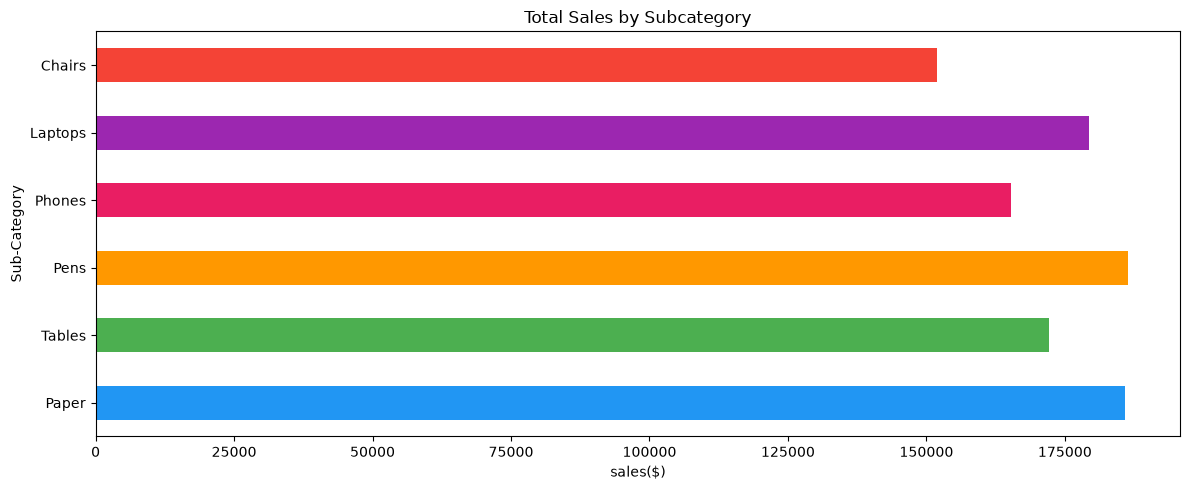

In [41]:
fig, ax1= plt.subplots( figsize =(12,5))
subcategory_summary['sales'].plot(kind='barh', ax=ax1, color = [
    '#2196F3',  # Blue
    '#4CAF50',  # Green
    '#FF9800',  # Orange
    '#E91E63',  # Pink
    '#9C27B0',  # Purple
    '#F44336'   # Red
])

ax1.set_title('Total Sales by Subcategory')
ax1.set_xlabel('sales($)')
ax1.set_ylabel('Sub-Category')

plt.tight_layout()
plt.savefig('../output/subcategory_analysis.png', dpi=150)
plt.show()

In [42]:
discount_analysis = df_all_region.groupby('discount')[['sales', 'profit']].mean()
print("---- Average Sales & Profit by Discount ----")
print(discount_analysis)

---- Average Sales & Profit by Discount ----
                sales      profit
discount                         
0.0       1021.440242  242.651290
0.1       1052.885322  243.302575
0.2       1009.715494  201.058142
0.3       1079.739361  184.618308


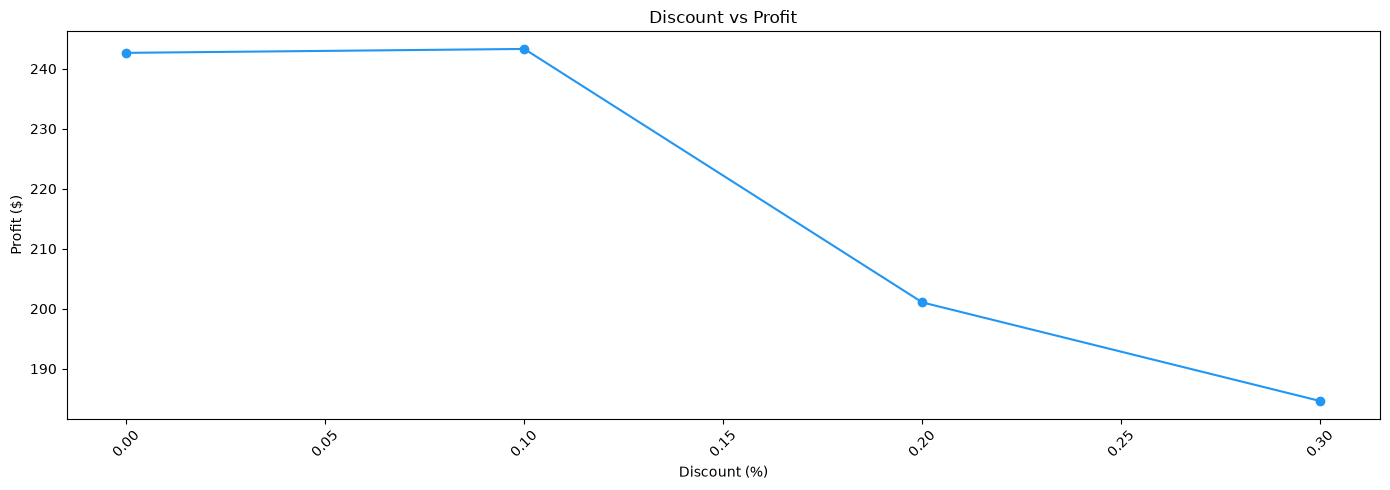

In [47]:
discount_analysis = df_all_region.groupby('discount')[['sales', 'profit']].mean().reset_index()
plt.figure(figsize=(14, 5))
plt.plot(discount_analysis['discount'], discount_analysis['profit'],  color='#2196F3', marker='o')
plt.title('Discount vs Profit')
plt.xlabel('Discount (%)')
plt.ylabel('Profit ($)')
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../output/discount_analysis.png', dpi=150)
plt.show()


In [48]:
region_subcategory = df_all_region.groupby(['region', 'sub_category'])['profit'].sum().reset_index()
print(region_subcategory.head(10))

  region sub_category    profit
0   East       Chairs   7413.18
1   East      Laptops   9512.83
2   East        Paper  13614.31
3   East         Pens   8023.45
4   East       Phones   7105.34
5   East       Tables   8910.68
6  North       Chairs   6227.13
7  North      Laptops  10216.20
8  North        Paper   9606.29
9  North         Pens   7237.50


In [64]:
top3_region = region_subcategory.sort_values('profit', ascending=False).groupby('region').head(3).sort_values('region')

print("---- Top 3 Sub-Categories by Region ----")
print(top3_region)

---- Top 3 Sub-Categories by Region ----
   region sub_category    profit
2    East        Paper  13614.31
1    East      Laptops   9512.83
5    East       Tables   8910.68
11  North       Tables  10402.07
7   North      Laptops  10216.20
10  North       Phones   9883.27
16  South       Phones  10002.08
15  South         Pens   9288.72
12  South       Chairs   8868.96
21   West         Pens  12420.34
23   West       Tables  10526.32
18   West       Chairs   9243.97
